# V1 — BraTS-GLI Dataset Exploration

This notebook explores the BraTS-GLI 2023 training dataset for brain tumor MRI segmentation.

### Objectives

- Load 3D MRI volumes in NIfTI format
- Understand the dataset structure
- Inspect MRI dimensions and metadata
- Visualize MRI slices
- Load and analyze segmentation masks
- Understand tumor sub-regions
- Analyze class imbalance
- Calculate tumor volume from voxel spacing

--- 

## 1. Imports

We use **NiBabel** to read NIfTI medical imaging files, **NumPy** for numerical operations, and **Matplotlib** for visualization.

In [ ]:
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

## 2. Dataset Path

The BraTS-GLI training dataset is stored locally under `data/raw/`.

Each patient has a separate directory containing four MRI modalities and a ground-truth segmentation mask.

In [4]:
from pathlib import Path

patient_dir = Path(
    "../data/raw/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/"
    "BraTS-GLI-00324-000"
)

t1n_path = patient_dir / "BraTS-GLI-00324-000-t1n.nii.gz"

print(t1n_path)

../data/raw/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00324-000/BraTS-GLI-00324-000-t1n.nii.gz


In [8]:
t1n_img = nib.load(t1n_path)

print(t1n_img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (240, 240, 155)
affine:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b   

In [9]:
print("Shape:", t1n_img.shape)
print("Data type:", t1n_img.get_data_dtype())

Shape: (240, 240, 155)
Data type: int16


---

## 3. Converting the NIfTI Volume to NumPy

After loading the NIfTI file with NiBabel, we extract its voxel data as a NumPy array.

The resulting array represents the intensity value of every voxel in the 3D MRI volume.

In [10]:
t1n = t1n_img.get_fdata()

print("Type:", type(t1n))
print("Shape:", t1n.shape)

Type: <class 'numpy.ndarray'>
Shape: (240, 240, 155)


In [11]:
slice_idx = t1n.shape[2] // 2

t1n_slice = t1n[:, :, slice_idx]

print("Slice index:", slice_idx)
print("Slice shape:", t1n_slice.shape)

Slice index: 77
Slice shape: (240, 240)


---

## 4. Visualizing a 2D MRI Slice

A 3D MRI volume can be viewed as a sequence of 2D slices.

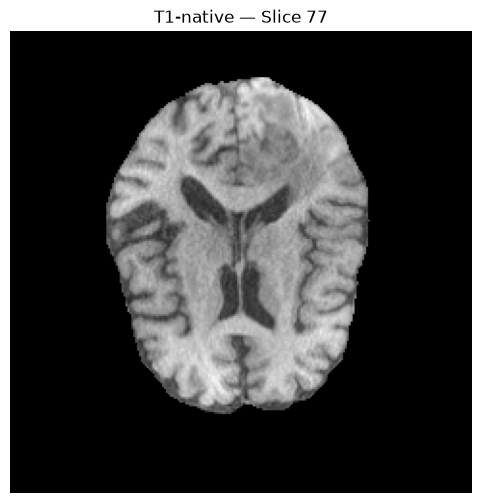

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    t1n_slice.T,
    cmap="gray",
    origin="lower"
)

plt.title(f"T1-native — Slice {slice_idx}")
plt.axis("off")

plt.show()

---

## 5. Loading the Segmentation Mask

The segmentation file contains the ground-truth tumor annotations.

Unlike MRI volumes, which contain continuous intensity values, the segmentation mask contains discrete class labels.

Each voxel is assigned to a specific anatomical/tumor region.

In [13]:
seg_path = patient_dir / "BraTS-GLI-00324-000-seg.nii.gz"

print(seg_path)

../data/raw/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00324-000/BraTS-GLI-00324-000-seg.nii.gz


In [14]:
seg_img = nib.load(seg_path)

print("Shape:", seg_img.shape)
print("Data type:", seg_img.get_data_dtype())

Shape: (240, 240, 155)
Data type: float32


In [15]:
seg = seg_img.get_fdata()

print("Type:", type(seg))
print("Shape:", seg.shape)

Type: <class 'numpy.ndarray'>
Shape: (240, 240, 155)


In [ ]:
print("Unique labels:", np.unique(seg))

Unique labels: [0. 1. 2. 3.]


---

## 6. Segmentation Labels

The BraTS-GLI dataset used in this project contains four segmentation labels:

| Label | Region |
|---:|---|
| 0 | Background |
| 1 | Necrotic / non-enhancing tumor |
| 2 | Edema |
| 3 | Enhancing tumor |

Therefore:

$
Y \in \{0,1,2,3\}
$

where $Y$ is the segmentation mask.

In [17]:
labels, counts = np.unique(seg, return_counts=True)

for label, count in zip(labels, counts):
    print(f"Label {int(label)}: {count:,} voxels")

Label 0: 8,844,582 voxels
Label 1: 1,588 voxels
Label 2: 75,783 voxels
Label 3: 6,047 voxels


In [18]:
tumor_slices = np.where(
    np.any(seg > 0, axis=(0, 1))
)[0]

print("Number of tumor-containing slices:", len(tumor_slices))
print("First tumor slice:", tumor_slices[0])
print("Last tumor slice:", tumor_slices[-1])

Number of tumor-containing slices: 76
First tumor slice: 52
Last tumor slice: 127


In [19]:
slice_idx = 90

flair_slice = volumes["flair"][:, :, slice_idx] if "volumes" in globals() else None

In [20]:
t1n_slice = t1n[:, :, slice_idx]
seg_slice = seg[:, :, slice_idx]

print("MRI slice shape:", t1n_slice.shape)
print("Segmentation slice shape:", seg_slice.shape)
print("Labels in this slice:", np.unique(seg_slice))

MRI slice shape: (240, 240)
Segmentation slice shape: (240, 240)
Labels in this slice: [0. 1. 2. 3.]


---

## 7. Tumor-Containing Slices

Not every MRI slice contains tumor tissue.

We identify slices where at least one voxel has a non-zero segmentation label.

This allows us to determine the range of slices containing tumor and will later be useful for visualization and dataset sampling.

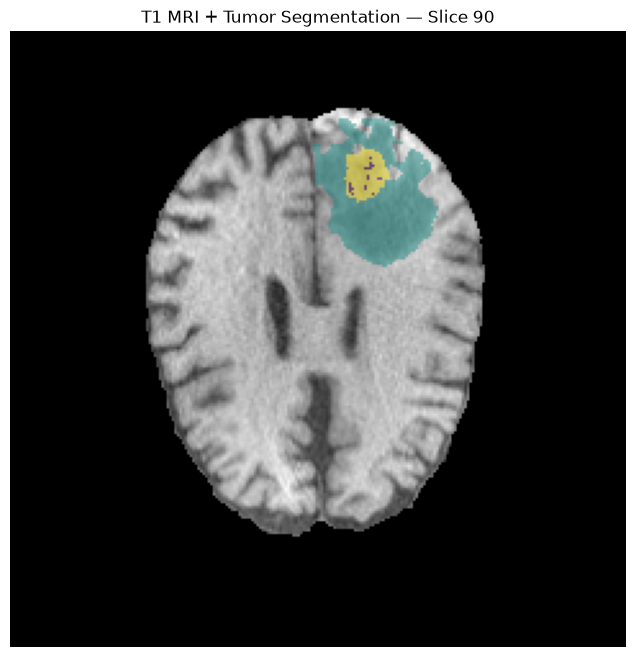

In [21]:
plt.figure(figsize=(8, 8))

plt.imshow(
    t1n_slice.T,
    cmap="gray",
    origin="lower"
)

plt.imshow(
    np.ma.masked_where(seg_slice.T == 0, seg_slice.T),
    alpha=0.5,
    origin="lower"
)

plt.title("T1 MRI + Tumor Segmentation — Slice 90")
plt.axis("off")

plt.show()

In [22]:
label_1 = seg_slice == 1
label_2 = seg_slice == 2
label_3 = seg_slice == 3

---

## 8. Individual Tumor Regions

The tumor is not treated as a single homogeneous region.

The segmentation contains three tumor-related classes:

- Necrotic / non-enhancing tumor
- Edema
- Enhancing tumor

Visualizing these classes separately helps us understand the spatial structure that the future model must learn.

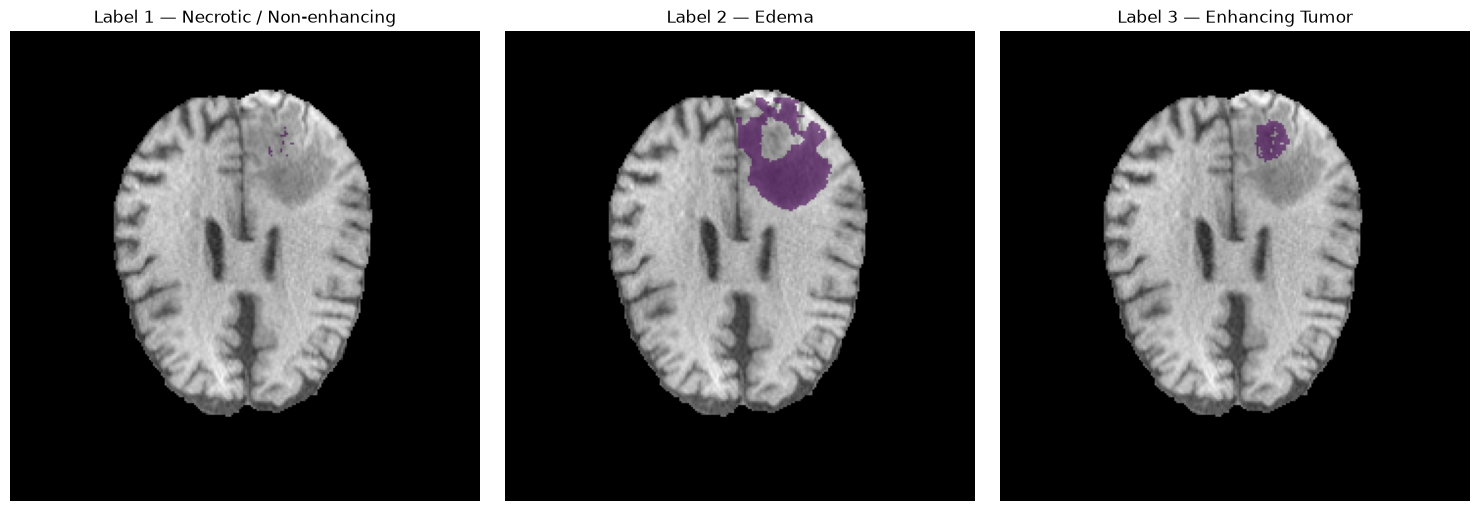

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = [1, 2, 3]
masks = [label_1, label_2, label_3]
titles = [
    "Label 1 — Necrotic / Non-enhancing",
    "Label 2 — Edema",
    "Label 3 — Enhancing Tumor"
]

for ax, mask, title in zip(axes, masks, titles):
    ax.imshow(
        t1n_slice.T,
        cmap="gray",
        origin="lower"
    )
    
    ax.imshow(
        np.ma.masked_where(~mask.T, mask.T),
        alpha=0.6,
        origin="lower"
    )
    
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
print("Voxel spacing:", seg_img.header.get_zooms()[:3])

Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


---

## 9. Tumor Volume

Tumor volume is calculated from the number of tumor voxels and the physical volume of each voxel.

$
V_{tumor} = N_{tumor}\times V_{voxel}
$

Since:

$
1\ cm^3 = 1000\ mm^3
$

we convert the final volume from $mm^3$ to $cm^3$ by dividing by 1000.

In [25]:
voxel_spacing = np.array(seg_img.header.get_zooms()[:3])

voxel_volume_mm3 = np.prod(voxel_spacing)

# Individual regions
label_1_voxels = np.sum(seg == 1)
label_2_voxels = np.sum(seg == 2)
label_3_voxels = np.sum(seg == 3)

# Whole tumor
whole_tumor_voxels = np.sum(seg > 0)

# Convert to physical volume
label_1_volume_mm3 = label_1_voxels * voxel_volume_mm3
label_2_volume_mm3 = label_2_voxels * voxel_volume_mm3
label_3_volume_mm3 = label_3_voxels * voxel_volume_mm3
whole_tumor_volume_mm3 = whole_tumor_voxels * voxel_volume_mm3

# mm³ → cm³
label_1_volume_cm3 = label_1_volume_mm3 / 1000
label_2_volume_cm3 = label_2_volume_mm3 / 1000
label_3_volume_cm3 = label_3_volume_mm3 / 1000
whole_tumor_volume_cm3 = whole_tumor_volume_mm3 / 1000

print(f"Voxel volume: {voxel_volume_mm3:.2f} mm³")
print()

print(f"Label 1 volume: {label_1_volume_mm3:.2f} mm³ "
      f"({label_1_volume_cm3:.3f} cm³)")

print(f"Label 2 volume: {label_2_volume_mm3:.2f} mm³ "
      f"({label_2_volume_cm3:.3f} cm³)")

print(f"Label 3 volume: {label_3_volume_mm3:.2f} mm³ "
      f"({label_3_volume_cm3:.3f} cm³)")

print()

print(f"Whole tumor volume: {whole_tumor_volume_mm3:.2f} mm³ "
      f"({whole_tumor_volume_cm3:.3f} cm³)")

Voxel volume: 1.00 mm³

Label 1 volume: 1588.00 mm³ (1.588 cm³)
Label 2 volume: 75783.00 mm³ (75.783 cm³)
Label 3 volume: 6047.00 mm³ (6.047 cm³)

Whole tumor volume: 83418.00 mm³ (83.418 cm³)


---

### Key Takeaway

Brain tumor segmentation is a **3D voxel-level prediction problem**.

The future model will take multiple MRI modalities as input and predict a segmentation label for every voxel:

$$
[T1n,T1c,T2w,T2f]
\rightarrow
Segmentation
$$

The next stage is **V1.5**, where we convert this exploratory notebook code into a reusable patient-level data pipeline.